CATS

1. IMPORTS

In [69]:
###CATS Iniciales

### SETUP

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

2. GEGLU

In [70]:
class GEGLU(nn.Module):
  def forward(self, x):
    x, gate = x.chunk(2, dim =- 1)
    r = x * F.gelu(gate)
    return r

In [71]:
### C


class QueryAdaptiveMasking(nn.Module):

  def __init__(self, dim = 1, start_prob = 0.1, end_prob = 0.5):

    super().__init__()

    self.dim = dim
    self.start_prob = start_prob
    self.end_prob = end_prob

  def forward(self, x):
    if not self.training:
      return x
    else:
      size = x.shape[self.dim]

      target_size = x.shape[self.dim]

      dropout_probs = torch.linspace(self.start_prob,
                                     self.end_prob,
                                     steps = target_size,
                                     device = x.device)

      reshape_pattern = [
          -1 if i == self.dim else 1
          for i in range(x.dim())
      ]

      dropout_probs = dropout_probs.view(reshape_pattern)

      mask = torch.bernoulli(1 - dropout_probs).expand_as(x)
      return x * mask

In [72]:
### B

class Projection(nn.Module):

  def __init__(self, d_model, patch_len):

    super().__init__()
    self.linear = nn.Linear(d_model, patch_len)
    self.flatten = nn.Flatten(start_dim = -2)

  def forward(self, x):
    x = self.linear(x)
    x = self.flatten(x)
    return x


In [73]:
### B.2

class Model_backbone(nn.Module):
  def __init__(self, c_in:int, seq_len:int, pred_len:int,
               patch_len:int=24, stride:int=24, n_layers:int=3,
               d_model=128, n_heads=16, d_ff:int=256,
               attn_dropout:float=0., dropout:float=0.,
               res_attention:bool=True, independence:bool=False,
               store_attn:bool=False, QAM_start:float = 0.1,
                QAM_end:float =0.5, padding_patch = None, **kwargs):

    super().__init__()


    self.patch_len = patch_len
    self.stride = stride
    self.padding_patch = padding_patch
    pred_patch_num = (pred_len+patch_len-1)//patch_len
    seq_patch_num = int((seq_len - patch_len)/stride + 1)

    if padding_patch == 'end':
      self.padding_patch_layer = nn.ReplicationPad1d((0, stride))
      seq_patch_num += 1

    self.backbone = Dummy_Embedding(c_in, seq_patch_num=seq_patch_num,
                                    patch_len=patch_len,
                                    pred_patch_num=pred_patch_num,
                                    n_layers=n_layers, d_model=d_model,
                                    n_heads=n_heads, d_ff=d_ff,
                                    attn_dropout=attn_dropout,
                                    dropout=dropout, QAM_start=QAM_start,
                                    QAM_end=QAM_end,
                                    res_attention=res_attention,
                                    independence = independence,
                                    store_attn=store_attn, **kwargs)


    self.n_vars = c_in
    self.pred_len = pred_len
    self.proj = Projection(d_model, patch_len)

  def forward(self, z):
    mean = z.mean(2, keepdim=True)
    std = torch.sqrt(torch.var(z, dim=2, keepdim=True, unbiased=False) + 1e-5)
    z = (z - mean)/std

    if self.padding_patch == 'end':
      z = self.padding_patch_layer(z)

    z = z.unfold(dimension=-1, size=self.patch_len, step=self.stride)

    z = self.backbone(z)
    z = self.proj(z)

    z = z * (std[:, :, 0].unsqueeze(2).repeat(1, 1, self.pred_len))
    z = z + (mean[:, :, 0].unsqueeze(2).repeat(1, 1, self.pred_len))

    return z

In [74]:
### A

class _MultiheadAttention(nn.Module):

  def __init__(self, d_model, n_heads, res_attention=False, attn_dropout=0., proj_dropout=0., qkv_bias=True):

    super().__init__()

    d_h = d_model // n_heads

    self.scale = d_h ** -0.5
    self.n_heads = n_heads
    self.d_h = d_h

    self.W_Q = nn.Linear(d_model, d_h * n_heads, bias=qkv_bias)
    self.W_K = nn.Linear(d_model, d_h * n_heads, bias=qkv_bias)
    self.W_V = nn.Linear(d_model, d_h * n_heads, bias=qkv_bias)

    self.res_attention = res_attention
    self.attn_dropout = nn.Dropout(attn_dropout)
    self.to_out = nn.Sequential(nn.Linear(n_heads * d_h, d_model), nn.Dropout(proj_dropout))

  def forward(self, Q: Tensor, K: Tensor, V:Tensor, prev = None):

    bs = Q.size(0)
    q_s = self.W_Q(Q).view(bs, -1, self.n_heads, self.d_h)
    k_s = self.W_K(K).view(bs, -1,self.n_heads, self.d_h)
    v_s = self.W_V(V).view(bs, -1,self.n_heads, self.d_h)

    attn_scores = torch.einsum('bphd, bshd -> bphs', q_s, k_s) * self.scale

    if prev is not None:
      attn_scores = attn_scores + prev

    attn_weights = F.softmax(attn_scores, dim=-1)
    attn_weights = self.attn_dropout(attn_weights)

    output = torch.einsum('bphs, bshd -> bphd', attn_weights, v_s)
    output = output.contiguous().view(bs, -1, self.n_heads*self.d_h)
    output = self.to_out(output)

    if self.res_attention:
      return output, attn_weights, attn_scores
    else:
      return output, attn_weights

In [75]:
### A.2

class DecoderLayer(nn.Module):

  def __init__(self, seq_patch_num, d_model, pred_patch_num, n_heads,
               d_ff=256,
               store_attn=False, QAM_start = 0.1, QAM_end =0.5,
              attn_dropout=0, dropout=0., bias=True, res_attention=False):


    assert d_ff % 2 == 0, f"d_ff DEBE SER PAR  {d_ff}"
    super().__init__()



    self.res_attention = res_attention
    self.cross_attn = _MultiheadAttention(d_model,
                                          n_heads,
                                          attn_dropout=attn_dropout,
                                          proj_dropout=dropout,
                                          res_attention=res_attention)



    self.dropout_attn = QueryAdaptiveMasking(dim=1,
                                             start_prob=QAM_start,
                                             end_prob=QAM_end)

    self.norm_attn = nn.LayerNorm(d_model)

    self.ffn = nn.Sequential(nn.Linear(d_model, d_ff, bias=bias),
                             GEGLU(),
                             nn.Dropout(dropout),
                             nn.Linear(d_ff//2, d_model, bias=bias))

    self.dropout_ffn = QueryAdaptiveMasking(dim=1,
                                            start_prob=QAM_start,
                                            end_prob=QAM_end)

    self.norm_ffn = nn.LayerNorm(d_model)
    self.store_attn = store_attn

  def forward(self, seq:Tensor, pred: Tensor, prev= None) -> Tensor:

    if self.res_attention:

      pred2, attn, scores = self.cross_attn(pred, seq, seq, prev)

    else:

      pred2, attn = self.cross_attn(pred, seq, seq)

    if self.store_attn:

      self.attn = attn

    pred = pred + self.dropout_attn(pred2)
    pred = self.norm_attn(pred)

    pred2 = self.ffn(pred)

    pred = pred + self.dropout_ffn(pred2)
    pred = self.norm_ffn(pred)

    if self.res_attention:
      return seq, pred, scores

    else:
      return seq, pred


In [76]:
### A.3

class Decoder(nn.Module):

  def __init__(self, seq_patch_num, d_model, n_heads, pred_patch_num,
               d_ff=None, attn_dropout=0., dropout=0.,
               QAM_start=0.1, QAM_end=0.5,
               res_attention=False, n_layers=1, store_attn=False):

    super().__init__()
    self.res_attention = res_attention

    layers = []

    for i in range(n_layers):

      layer = DecoderLayer(
                seq_patch_num=seq_patch_num,
                d_model=d_model,
                pred_patch_num=pred_patch_num,
                n_heads=n_heads,
                d_ff=d_ff,
                QAM_start=QAM_start,
                QAM_end=QAM_end,
                attn_dropout=attn_dropout,
                dropout=dropout,
                res_attention=res_attention,
                store_attn=store_attn
            )
      layers.append(layer)

    self.layers = nn.ModuleList(layers)

  def forward(self, seq: Tensor, pred: Tensor):
    scores = None

    if self.res_attention:
      for mod in self.layers:
        seq, pred, scores = mod(seq, pred, prev=scores)

      return pred

    else:
      for mod in self.layers:
        seq, pred = mod(seq, pred)

      return pred

In [77]:
### A.4

class Dummy_Embedding(nn.Module):

  def __init__(self, c_in, seq_patch_num, patch_len, pred_patch_num,
               n_layers=3, d_model=128, n_heads=16, QAM_start = 0.1,
               QAM_end =0.5, d_ff=256, attn_dropout=0., dropout=0.,
               store_attn=False, res_attention=True, independence = False,
               **kwargs):

    super().__init__()


    self.W_P = nn.Linear(patch_len, d_model)
    self.dropout = nn.Dropout(dropout)

    self.independence = independence

    if self.independence:
      self.dummies = nn.Parameter(0.5*torch.randn(pred_patch_num, patch_len))

    else:
      self.dummies = nn.Parameter(0.5*torch.randn(c_in, pred_patch_num, patch_len))

    self.independence = independence

    self.PE = nn.Parameter(0.04*torch.rand(seq_patch_num, d_model)-0.02)

    self.decoder = Decoder(seq_patch_num, d_model, n_heads, pred_patch_num,
                           d_ff=d_ff, attn_dropout=attn_dropout,
                           dropout=dropout, QAM_start=QAM_start,
                           QAM_end=QAM_end, res_attention=res_attention,
                           n_layers=n_layers, store_attn=store_attn)




  def forward(self, x) -> Tensor:

    bs = x.shape[0]
    n_vars = x.shape[1]


    x = self.W_P(x) + self.PE
    dummies = self.W_P(self.dummies)
    x = torch.reshape(x, (bs* n_vars, x.shape[2], x.shape[3]))

    seq_patch = self.dropout(x)

    if self.independence:
      pred_patch = dummies.unsqueeze(0).repeat(bs*n_vars,1,1)

    else:
      pred_patch = dummies.unsqueeze(0).repeat(bs,1,1,1)
      pred_patch = torch.reshape(pred_patch, (bs*n_vars,pred_patch.shape[2],pred_patch.shape[3]))



    z = self.decoder(seq_patch, pred_patch)
    z = torch.reshape(z, (-1, n_vars, z.shape[-2], z.shape[-1]))
    return z


In [78]:
### La clase madre

class Model(nn.Module):

  def __init__(self, args, **kwargs):

    super().__init__()

    c_in = args.dec_in
    seq_len = args.seq_len
    self.pred_len = args.pred_len
    n_layers = args.d_layers
    n_heads = args.n_heads

    d_model = args.d_model
    d_ff = args.d_ff

    dropout = args.dropout

    independence = args.query_independence

    patch_len = args.patch_len

    stride = args.stride

    padding_patch = args.padding_patch

    store_attn = args.store_attn

    QAM_start = args.QAM_start

    QAM_end = args.QAM_end

    self.model = Model_backbone(c_in=c_in,
                                seq_len = seq_len,
                                pred_len=self.pred_len,
                                patch_len=patch_len,
                                stride=stride, n_layers=n_layers,
                                d_model=d_model, n_heads=n_heads,
                                d_ff=d_ff,
                                dropout=dropout,
                                independence=independence,
                                store_attn=store_attn,
                                padding_patch = padding_patch,
                                QAM_start=QAM_start,
                                QAM_end=QAM_end, **kwargs)


  def forward(self, x):

    x = x.permute(0,2,1)

    x = self.model(x)

    x = x.permute(0,2,1)

    return x[:,:self.pred_len, :]

In [79]:
from argparse import Namespace

args_test = Namespace(
    dec_in=7, seq_len=96, pred_len=96,
    d_layers=3, n_heads=32, d_model=256, d_ff=512,
    dropout=0.2, query_independence=False,
    patch_len=48, stride=48, padding_patch='end',
    store_attn=False, QAM_start=0.1, QAM_end=0.2,
)

_m = Model(args_test)
_n = sum(p.numel() for p in _m.parameters())
#print(f"Parametros: {_n:,}")


_x = torch.randn(4, 96, 7)
_y = _m(_x)

print(f"Input : {tuple(_x.shape)}")
print(f"Output: {tuple(_y.shape)}")

_m.train()
loss = _m(_x).mean()
loss.backward()
print("weee woooo")


Input : (4, 96, 7)
Output: (4, 96, 7)
weee woooo


EXPERIMENTOS

In [80]:
import numpy as np

import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

import time
from torch.optim import lr_scheduler


import matplotlib.pyplot as plt

In [95]:
class Configs:
    def __init__(self):
        self.root_path = './Datasets/'
        self.data_path = 'ETTh1.csv'
        self.features = 'M'
        self.target = 'OT'

        self.seq_len = 96
        self.pred_len = 96
        self.dec_in = 7 ########### 8 exchange / 7 ETTh

        self.patch_len = 16
        self.stride = 16
        self.padding_patch = 'end'

        self.d_model = 128
        self.n_heads = 16
        self.d_ff = 256
        self.d_layers = 3
        self.dropout = 0.2
        self.query_independence = False
        self.store_attn = False

        self.QAM_start = 0.1
        self.QAM_end = 0.2

        self.train_epochs = 100
        self.batch_size = 128
        self.learning_rate = 1e-3
        self.patience = 100
        self.pct_start = 0.3

        self.train_ratio = 0.7
        self.test_ratio = 0.2

configs = Configs()


In [96]:
class Dataset_Finance(Dataset):

    def __init__(self, configs, flag='train'):

        self.flag = flag
        self.set_type = {'train': 0, 'val': 1, 'test': 2}[flag]
        self.cfg = configs
        self.seq_len = configs.seq_len
        self.pred_len = configs.pred_len
        self._read_data()

    def _read_data(self):

        cfg = self.cfg
        self.scaler = StandardScaler()
        df_raw = pd.read_csv(os.path.join(cfg.root_path, cfg.data_path))

        cols = list(df_raw.columns)
        if 'date' in cols:

            cols.remove('date')
        if cfg.target in cols:

            cols.remove(cfg.target)

        ordered = (['date'] if 'date' in df_raw.columns else []) + cols + [cfg.target]
        df_raw = df_raw[ordered]

        n = len(df_raw)

        n_train = int(n * cfg.train_ratio)
        n_test  = int(n * cfg.test_ratio)
        n_val   = n - n_train - n_test
        border1s = [0, n_train - self.seq_len, n - n_test - self.seq_len]
        border2s = [n_train, n_train + n_val, n]
        b1, b2 = border1s[self.set_type], border2s[self.set_type]

        if cfg.features in ('M', 'MS'):

            df_data = df_raw[df_raw.columns[1:]] if 'date' in df_raw.columns else df_raw
        else:

            df_data = df_raw[[cfg.target]]

        train_data = df_data[border1s[0]:border2s[0]]
        self.scaler.fit(train_data.values)
        data = self.scaler.transform(df_data.values)

        self.data_x = data[b1:b2]
        self.data_y = data[b1:b2, -1:] if cfg.features == 'MS' else data[b1:b2]

    def __getitem__(self, idx):

        s_begin = idx
        s_end = s_begin + self.seq_len
        r_begin = s_end
        r_end = r_begin + self.pred_len
        x = self.data_x[s_begin:s_end]
        y = self.data_y[r_begin:r_end]

        return torch.from_numpy(x).float(), torch.from_numpy(y).float()

    def __len__(self):

        return len(self.data_x) - self.seq_len - self.pred_len + 1

    def inverse_transform(self, data):

        return self.scaler.inverse_transform(data)


def get_loaders(configs):
    loaders = {}
    sets = {}

    for flag in ('train', 'val', 'test'):

        ds = Dataset_Finance(configs, flag=flag)
        shuffle = (flag == 'train')
        loader = DataLoader(ds, batch_size=configs.batch_size, shuffle=shuffle, drop_last=(flag == 'train'))
        sets[flag] = ds
        loaders[flag] = loader
    return sets, loaders


In [97]:

def MAE(pred, true):
    return np.mean(np.abs(pred - true))

def MSE(pred, true):
    return np.mean((pred - true) ** 2)

def RSE(pred, true):
    return np.sqrt(np.sum((true - pred) ** 2)) / np.sqrt(np.sum((true - true.mean()) ** 2))

def RMSE(pred, true):
    return np.sqrt(MSE(pred, true))


def metric(pred, true):
    mae = MAE(pred, true)
    mse = MSE(pred, true)
    rse = RSE(pred, true)
    rmse = RMSE(pred, true)

    return mae, mse, rmse, rse


In [98]:
class EarlyStopping:
    def __init__(self, patience=100, verbose=True, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta

    def __call__(self, val_loss, model, path):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self._save(val_loss, model, path)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"  EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self._save(val_loss, model, path)
            self.counter = 0

    def _save(self, val_loss, model, path):
        if self.verbose:
            print(f"  Val loss {self.val_loss_min:.6f} -> {val_loss:.6f}. GUARDANDO.")
        torch.save(model.state_dict(), path)
        self.val_loss_min = val_loss


def run_experiment(configs, checkpoint_path='./best_cats.pth', verbose=True):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if verbose:
        print(f"Device: {device}")

    sets, loaders = get_loaders(configs)
    train_loader, val_loader, test_loader = loaders['train'], loaders['val'], loaders['test']

    model = Model(configs).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    if verbose:
        print(f"Parametros del modelo: {n_params:,}\n")

    optimizer = torch.optim.Adam(model.parameters(), lr=configs.learning_rate)
    criterion = nn.MSELoss()
    train_steps = len(train_loader)
    scheduler = lr_scheduler.OneCycleLR(optimizer, max_lr=configs.learning_rate,
                                        steps_per_epoch=train_steps,
                                        epochs=configs.train_epochs,
                                        pct_start=configs.pct_start)

    early_stop = EarlyStopping(patience=configs.patience, verbose=verbose)

    for epoch in range(configs.train_epochs):
        model.train()
        t0 = time.time()
        train_losses = []
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_losses.append(loss.item())

        # validacion
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                val_losses.append(criterion(model(x), y).item())

        tr, vl = np.mean(train_losses), np.mean(val_losses)
        if verbose:
            print(f"Epoca {epoch+1:2d}/{configs.train_epochs} | "
                  f"train MSE {tr:.4f} | val MSE {vl:.4f} | {time.time()-t0:.1f}s")

        early_stop(vl, model, checkpoint_path)
        if early_stop.early_stop:
            if verbose: print("Early stopping.")
            break

    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    return model, sets, loaders, device

In [99]:
model, sets, loaders, device = run_experiment(configs)

model.eval()
preds, trues, lasts = [], [], []
with torch.no_grad():
    for x, y in loaders['test']:
        x = x.to(device)
        out = model(x).cpu().numpy()
        preds.append(out)
        trues.append(y.numpy())

preds = np.concatenate(preds, 0)
trues = np.concatenate(trues, 0)

mae, mse, rmse, rse = metric(preds, trues)

print("TEST")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"RSE  : {rse:.4f}")


Device: cuda
Parametros del modelo: 354,096

Epoca  1/100 | train MSE 0.6661 | val MSE 0.5662 | 1.9s
  Val loss inf -> 0.566215. GUARDANDO.
Epoca  2/100 | train MSE 0.6041 | val MSE 0.5467 | 1.8s
  Val loss 0.566215 -> 0.546703. GUARDANDO.
Epoca  3/100 | train MSE 0.5897 | val MSE 0.5409 | 2.0s
  Val loss 0.546703 -> 0.540892. GUARDANDO.
Epoca  4/100 | train MSE 0.5820 | val MSE 0.5332 | 1.9s
  Val loss 0.540892 -> 0.533237. GUARDANDO.
Epoca  5/100 | train MSE 0.5701 | val MSE 0.5114 | 1.8s
  Val loss 0.533237 -> 0.511369. GUARDANDO.
Epoca  6/100 | train MSE 0.5499 | val MSE 0.4918 | 1.8s
  Val loss 0.511369 -> 0.491794. GUARDANDO.
Epoca  7/100 | train MSE 0.5331 | val MSE 0.4796 | 1.8s
  Val loss 0.491794 -> 0.479603. GUARDANDO.
Epoca  8/100 | train MSE 0.5223 | val MSE 0.4713 | 1.8s
  Val loss 0.479603 -> 0.471264. GUARDANDO.
Epoca  9/100 | train MSE 0.5100 | val MSE 0.4469 | 1.9s
  Val loss 0.471264 -> 0.446925. GUARDANDO.
Epoca 10/100 | train MSE 0.4670 | val MSE 0.3824 | 2.0s
  Va

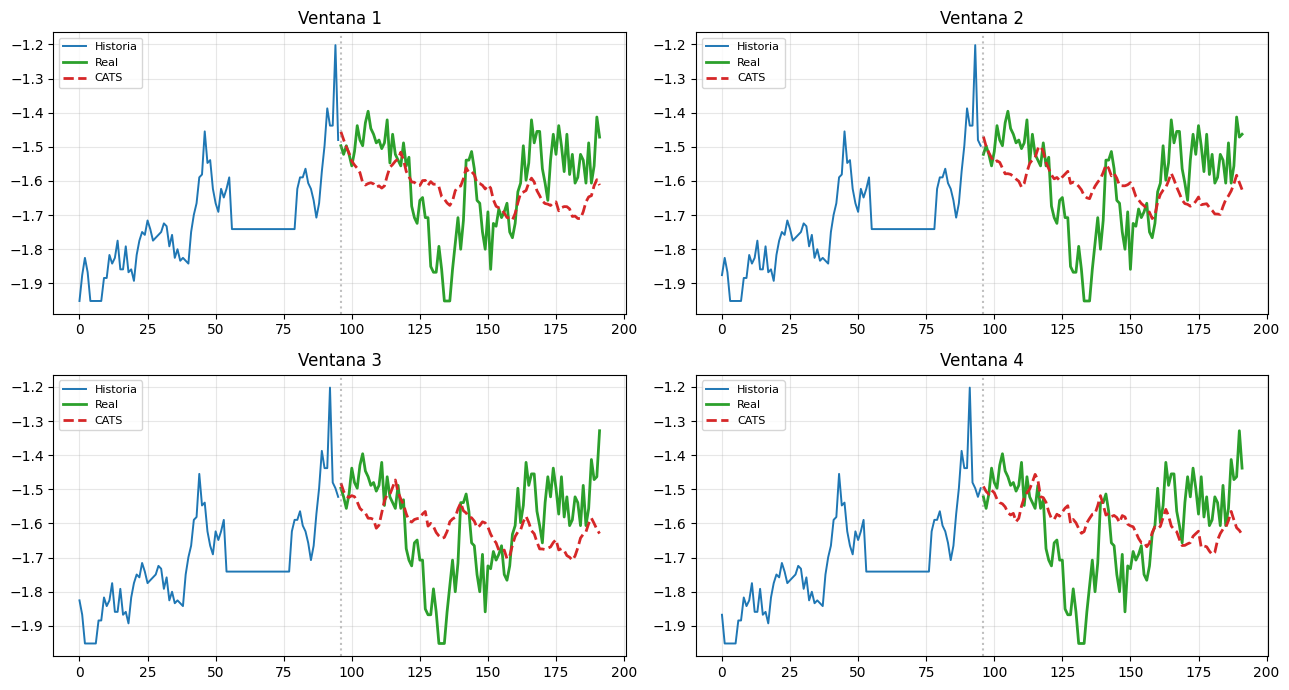

In [100]:

model.eval()
with torch.no_grad():
    for x, y in loaders['test']:
        x = x.to(device)
        pred = model(x).cpu().numpy()
        true = y.numpy()
        hist = x.cpu().numpy()
        break

ch = -1
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for i, ax in enumerate(axes.flat):
    h = hist[i, :, ch]
    p = pred[i, :, ch]
    t = true[i, :, ch]
    th = np.arange(len(h))
    tp = np.arange(len(h), len(h) + len(p))
    ax.plot(th, h, color='C0', lw=1.4, label='Historia')
    ax.plot(tp, t, color='C2', lw=2, label='Real')
    ax.plot(tp, p, color='C3', lw=2, ls='--', label='CATS')
    ax.axvline(len(h), color='gray', ls=':', alpha=0.5)
    ax.set_title(f'Ventana {i+1}')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


60 epocas original:

MSE:0.371
MAE:0.395
RMSE:0.609


10 epocas ETTH:

MSE  : 0.4195
MAE  : 0.4442
RMSE : 0.6477
RSE  : 0.5907

20 epocas:

MSE  : 0.4146
MAE  : 0.4420
RMSE : 0.6439
RSE  : 0.5872

70 epocas 3(mins)

MSE  : 0.4174
MAE  : 0.4441
RMSE : 0.6461
RSE  : 0.5892


Exchange
20 epocas:

MSE  : 0.0836
MAE  : 0.2031
RMSE : 0.2891
RSE  : 0.2197

30 epocas:

MSE  : 0.0858
MAE  : 0.2053
RMSE : 0.2929
RSE  : 0.2226

40 epocas:

MSE  : 0.0867
MAE  : 0.2047
RMSE : 0.2945
RSE  : 0.2238

50 epocas:

MSE  : 0.0828
MAE  : 0.2027
RMSE : 0.2878
RSE  : 0.2187

60 epocas:

MSE  : 0.0868
MAE  : 0.2077
RMSE : 0.2947
RSE  : 0.2239

